In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import pickle
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MiniBatchKMeans
import re
import copy
from sklearn.neighbors import NearestNeighbors
import hdbscan
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram


import sklearn, matplotlib, scipy
import tensorflow as tf
from tensorflow import keras

In [2]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
# os.environ["PYTHONHASHSEED"] = "0"

In [2]:
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
# print(f"HDBSCAN version: {hdbscan.__version__}")

NumPy version: 1.24.4
Pandas version: 1.2.4
Scikit-learn version: 1.3.2
Matplotlib version: 3.4.1
Seaborn version: 0.11.1
SciPy version: 1.10.1
TensorFlow version: 2.7.0
Keras version: 2.7.0


In [190]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [193]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [3]:
## Definitions

## Defines

# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

def print_progress(iteration, total, prefix='', suffix='', decimals=1, length=50, fill='█', printEnd="\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

In [4]:
## Configs
base = '/media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN'
# out = f'{base}/Clustering/M01_Main'
out = f'{base}/Clustering/M06-3_DBSCAN'
ipt = f'{base}/Dataset'
SEED = 64

In [5]:
# CLUSTERING :: DATA IMPORT

# Data import
df = pd.read_csv(f"{ipt}/knn_prep-fin_M02-1.csv")
df.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
df.set_index('idx_code', inplace=True)
df

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (30,31,55,61,62,63,87,90,91,92) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bir1,bir2,bir3,bir4,promn,promd,prho,promh,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,1,0,0,0,1,0,0,0
1,1,2013-11-15,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,1,0,0,0,1,0,0,0
2,1,2013-11-15,1.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,1,0,0,0,1,0,0,0
3,1,2013-11-15,0.0,1.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,1,0,0,0,1,0,0,0
4,1,2013-11-11,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17824,0,2022-08-16,0.0,0.0,0.0,0.0,1.0,2022-08-08,11:00,0.0,...,1,0,1,0,0,0,1,0,0,0
17825,1,2022-04-07,1.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,1,0,1,0,0,0,1,0,0,0
17826,0,2022-04-17,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,0,1,0,0,0,1,0,0


In [6]:
## 특정 칼럼의 값을 가진 인원만 사용

col_name1 = 'iperr_2'
col_name2 = 'ntet_1'
value = 1

df = df[(df[col_name1] == value) | (df[col_name2] == value)]    # 'OR' condition
# df = df[df[col_name] == value]
num_rows = df.shape[0]
num_cols = df.shape[1]
summary_df = pd.DataFrame({
    'n_participants': [num_rows],
    'n_features': [num_cols]
})
file_name = col_name.split('_')[0] + '_Pos_DataSummary'

# summary_df.to_csv(f"{out}/{file_name}.csv", index=False)
# print(f"Data summary has been saved: {out}/{file_name}.csv")

df

NameError: name 'col_name' is not defined

In [6]:

drop_cols = ['apguk1', 'apguk5', 'fetc2', 'fetc', 'strduot', 'metc', 'ibifcmt', 'lbpdot'
             , 'bhdcut', 'bhtcut', 'iperrdt', 'phudot', 'phudstdt', 'sftum', 'sftuh', 'sftfudt'
             , 'sftthdt', 'birdm', 'birdh', 'sign'
             , 'promn'    # 01-24 추가됨
            ]

## 접두사로 시작하는 제거칼럼
# prefixes_to_drop = ['mcou_', 'fcou_', 'bsffs1_', 'bsffs2_', 'bsffs3_', 'menifs_']
# drop_cols += [col for col in df.columns if any(col.startswith(prefix) for prefix in prefixes_to_drop)]
datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
                 , 'acldt', 'birthdt', 'bsfdt1', 'bsfdt3', 'admd'
                 , 'prho', 'promd', 'promh', 'prdh', 'dth36dt'    # 01-24 추가됨 ('promh', 'prdh', 'dth36dt')
                 , 'fsfdt1', 'fsfdt2', 'birtm', 'bird']
drop_cols += datetime_cols
df = df.drop(columns=list(drop_cols))

tgt_cols = [col for col in df.columns if col in ['ntet', 'ntety', 'ntetoy'
                                                 , 'invfpod'
                                                 , 'iperr', 'iperroy']
            or any(col.startswith(prefix) for prefix in ['ntet', 'ntety', 'ntetoy'
                                                         , 'invfpod'
                                                         , 'iperr', 'iperroy'])
           ]
data = df.drop(columns=['death36'] + list(tgt_cols)
#                + list(drop_cols)
#                + list(datetime_cols)
              )

# 데이터 표준화 (이진 값을 제외하고 표준화 수행)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
df_scd = pd.DataFrame(scaled_data, index=data.index, columns=data.columns)

df_scd['death36'] = df['death36']

df_scd

,sex_sys_val,bir1,bir2,bir3,bir4,sterd1,sterd2,sterd4,apgs1,apgs5,...,menifs_12,menifs_13,menifs_31,menifs_17,menifs_8,menifs_6,menifs_33,menifs_18,menifs_34,death36
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
1,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
2,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.029210,-0.660141,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
3,1.00028,-0.441286,2.037134,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.526262,-0.072549,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
4,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17824,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0
17825,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-1.959000,-0.660141,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0
17826,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.964895,0.515043,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0


In [7]:
print(len(drop_cols))
print(len(datetime_cols))
print(len(tgt_cols))

42
21
18


In [8]:
for column in df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df[column].dtype}")
    print(f"유니크한 값:")
    print(df[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: bir1
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir2
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir3
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir4
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: sterd1
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: sterd2
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: sterd4
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          5.          6.          3.          7.          1.
  9.          8.          2.          4.75271096  0.         10.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 5.          6.          7.          8.          4.     

In [9]:
analyse_dataframe(df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
bir4,0,0.0,2
...,...,...,...
iperr_4,0,0.0,2
iperroy_1,0,0.0,2
iperroy_4,0,0.0,2
iperroy_3,0,0.0,2


In [10]:
analyse_dataframe(df_scd)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
bir4,0,0.0,2
...,...,...,...
menifs_6,0,0.0,1
menifs_33,0,0.0,2
menifs_18,0,0.0,2
menifs_34,0,0.0,2


In [11]:
for column in df_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_scd[column].dtype}")
    print(f"유니크한 값:")
    print(df_scd[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: float64
유니크한 값:
[ 1.00028048 -0.9997196 ]
----------------------------------------
칼럼 이름: bir1
데이터 타입: float64
유니크한 값:
[-0.44128558  2.26610623]
----------------------------------------
칼럼 이름: bir2
데이터 타입: float64
유니크한 값:
[-0.49088582  2.03713361]
----------------------------------------
칼럼 이름: bir3
데이터 타입: float64
유니크한 값:
[-0.12790909  7.8180529 ]
----------------------------------------
칼럼 이름: bir4
데이터 타입: float64
유니크한 값:
[-2.59521494e-02  3.85324539e+01]
----------------------------------------
칼럼 이름: sterd1
데이터 타입: float64
유니크한 값:
[-0.30319627  3.29819364]
----------------------------------------
칼럼 이름: sterd2
데이터 타입: float64
유니크한 값:
[-0.74312684  1.34566529]
----------------------------------------
칼럼 이름: sterd4
데이터 타입: float64
유니크한 값:
[-0.03514924 28.45011583]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[-0.46784273  0.02920981  0.52626235 -0.96489526  1.02331488 -1.95900033
  2.01741995  1.52036742 -1.4619478  -0.09370

In [9]:
# ntet_1
# iperr_2
# death36

# 생존과 사망 비율 계산 (%)
death_label_ratio = df['iperr_2'].value_counts(normalize=True) * 100

# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율

# 출력
print("[1-1, IPERR POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['iperr_2'] == 0])} / {len(df['iperr_2'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['iperr_2'] == 1])} / {len(df['iperr_2'])}")
print()


# 생존과 사망 비율 계산 (%)
death_label_ratio = df['ntet_1'].value_counts(normalize=True) * 100

# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율

# 출력
print("[1-2, NTET POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['ntet_1'] == 0])} / {len(df['ntet_1'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['ntet_1'] == 1])} / {len(df['ntet_1'])}")
print()


# 생존과 사망 비율 계산 (%)
death_label_ratio = df['death36'].value_counts(normalize=True) * 100

# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율

# 출력
print("[2]")
print("[df_scd (Processed df)]")
print(f"Survived (0): {survived_ratio:.2f}%")
print(f"Survived / Total : {len(df[df['death36'] == 0])} / {len(df['death36'])}")
print("&")
print(f"Died (1): {died_ratio:.2f}%")
print(f"Death / Total : {len(df[df['death36'] == 1])} / {len(df['death36'])}")
print()




## IPERR + NTET BOTH

conditioned_participants = len(df[(df['iperr_2'] == 1) & (df['ntet_1'] == 1)])

# 전체 데이터의 인원 수
total_participants = len(df)

# 조건에 맞는 데이터의 전체 데이터 대비 비율
conditioned_ratio = (conditioned_participants / total_participants) * 100

# 출력
print("[IPERR+NTET BOTH]")
print("[df_scd (Processed df)]")
print(f"Conditioned Participants (1 in both iperr_2 and ntet_1): {conditioned_participants}")
print(f"Conditioned Participants / Total : {conditioned_participants} / {total_participants} ({conditioned_ratio:.2f}%)")


[1-1, IPERR POS]
[df_scd (Processed df)]
Negatives (0): 97.62%
Negatives / Total : 17404 / 17829
&
Positives (1): 2.38%
Positives / Total : 425 / 17829

[1-2, NTET POS]
[df_scd (Processed df)]
Negatives (0): 93.41%
Negatives / Total : 16654 / 17829
&
Positives (1): 6.59%
Positives / Total : 1175 / 17829

[2]
[df_scd (Processed df)]
Survived (0): 98.09%
Survived / Total : 17489 / 17829
&
Died (1): 1.91%
Death / Total : 340 / 17829

[IPERR+NTET BOTH]
[df_scd (Processed df)]
Conditioned Participants (1 in both iperr_2 and ntet_1): 134
Conditioned Participants / Total : 134 / 17829 (0.75%)


In [10]:
df_scd

,sex_sys_val,bir1,bir2,bir3,bir4,sterd1,sterd2,sterd4,apgs1,apgs5,...,menifs_12,menifs_13,menifs_31,menifs_17,menifs_8,menifs_6,menifs_33,menifs_18,menifs_34,death36
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
1,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
2,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.029210,-0.660141,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
3,1.00028,-0.441286,2.037134,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.526262,-0.072549,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
4,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17824,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0
17825,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-1.959000,-0.660141,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0
17826,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.964895,0.515043,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0


In [11]:
save_dir = out

In [18]:
## WCSS_scores (MiniBatch K-means)

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9e34398ca0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9e343aec10>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9e343aedc0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9e343aeca0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9e34398ca0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9e34398ca0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9e34398ca0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

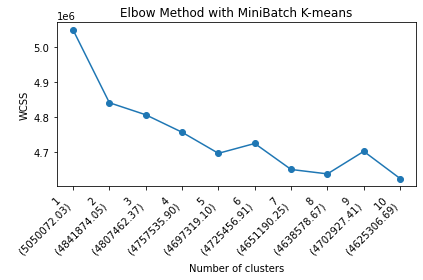

In [12]:
# df1 = pd.read_csv(os.path.join(data, "prep_origin_scd.csv"))
# df1 = df1.drop(columns=['Unnamed: 0'])

data_for_clustering = df_scd.drop(columns=['death36'])
data = data_for_clustering

# Initialise list(WCSS)
wcss = []

# MiniBatch KMeans 클러스터링 실행 및 WCSS 계산
for i in range(1, 11):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=i, batch_size=100, random_state=42)
    minibatch_kmeans.fit(data)
    wcss.append(minibatch_kmeans.inertia_)

# 그래프 생성
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method with MiniBatch K-means')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# X축 레이블을 클러스터 수와 WCSS 값을 포함한 괄호 형식으로 출력
x_labels = [f'{i} \n ({w:.2f})' for i, w in enumerate(wcss, 1)]
plt.xticks(range(1, 11), x_labels, rotation=45, ha='right')  # 49도 회전 및 오른쪽 정렬

# 그래프 표시
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "WCSS_plot.png"))
plt.show()

In [13]:
wcss

[5050072.034399599,
 4841874.049761146,
 4807462.365460513,
 4757535.904012696,
 4697319.100620147,
 4725456.914762243,
 4651190.25403598,
 4638578.6703402,
 4702927.410142497,
 4625306.69235056]

In [ ]:
## EPS calculation :: DBSCAN

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb77e497e50>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'



=== K = 1 ===
  min distance: 0.0000
  median distance: 0.0000
  90th percentile: 0.0000
  95th percentile: 0.0000
  max distance: 0.0000


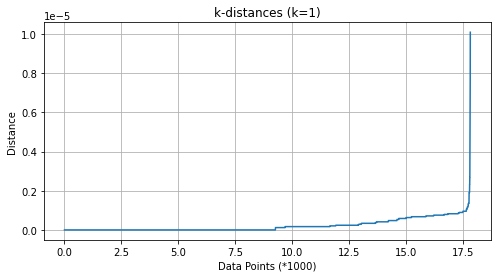

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb77e497e50>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'



=== K = 2 ===
  min distance: 0.7757
  median distance: 7.2686
  90th percentile: 12.9107
  95th percentile: 15.4672
  max distance: 189.3701


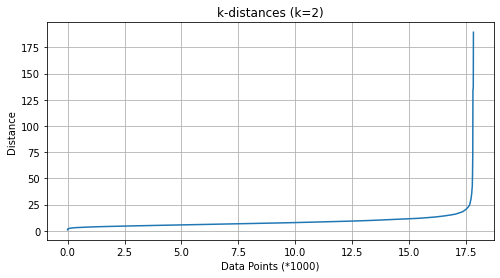

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb77e1833a0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'



=== K = 3 ===
  min distance: 2.1762
  median distance: 7.8405
  90th percentile: 13.7464
  95th percentile: 16.4006
  max distance: 189.4110


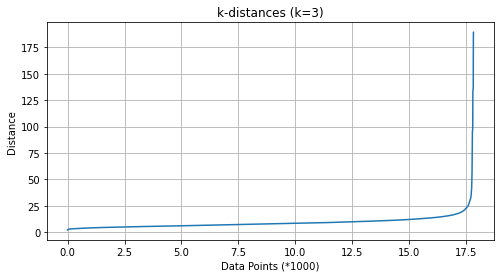

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb77e497e50>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'



=== K = 4 ===
  min distance: 2.5708
  median distance: 8.1372
  90th percentile: 14.1701
  95th percentile: 16.9725
  max distance: 189.4620


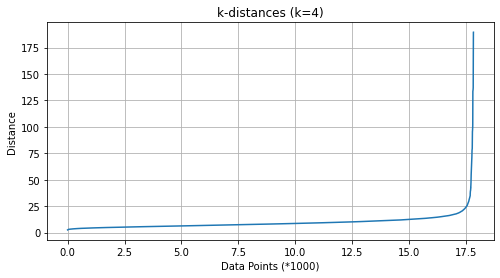

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb77e1833a0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'



=== K = 5 ===
  min distance: 2.6695
  median distance: 8.3382
  90th percentile: 14.4596
  95th percentile: 17.4988
  max distance: 189.4869


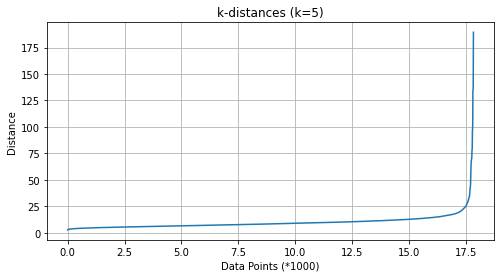

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb904c79ee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'



=== K = 6 ===
  min distance: 2.9398
  median distance: 8.4914
  90th percentile: 14.7049
  95th percentile: 17.8972
  max distance: 189.4881


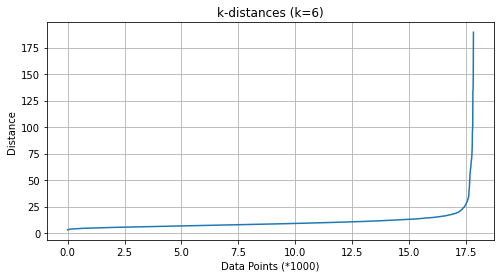

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb77e1833a0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'



=== K = 7 ===
  min distance: 3.1334
  median distance: 8.6048
  90th percentile: 14.8820
  95th percentile: 18.1744
  max distance: 189.4914


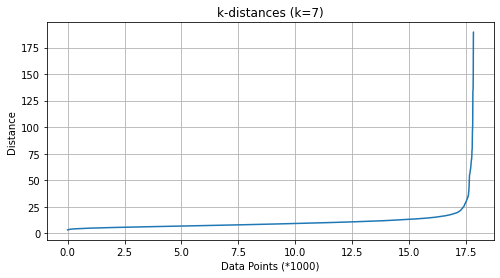

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb904c79ee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'



=== K = 8 ===
  min distance: 3.1882
  median distance: 8.7153
  90th percentile: 15.0386
  95th percentile: 18.5029
  max distance: 189.4927


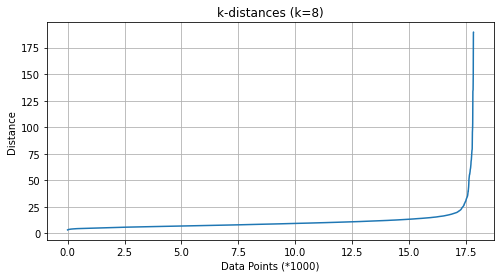

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb904b5b0d0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'



=== K = 9 ===
  min distance: 3.1932
  median distance: 8.8067
  90th percentile: 15.1959
  95th percentile: 18.7179
  max distance: 189.5024


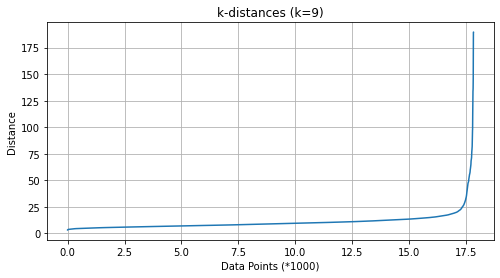

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb904ab9b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'



=== K = 10 ===
  min distance: 3.2726
  median distance: 8.8855
  90th percentile: 15.3305
  95th percentile: 18.9564
  max distance: 189.5272


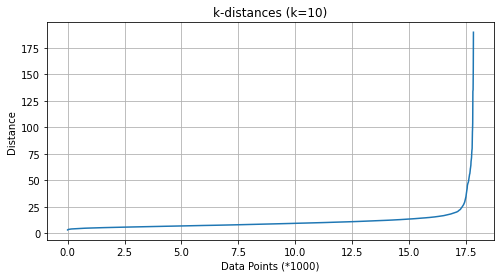

In [14]:
data_for_clustering = df_scd.drop(columns=['death36'])

# k를 1부터 10까지 시도
k_values = range(1, 11)

for k in k_values:
    print(f"\n=== K = {k} ===")
    
    # 주의: n_neighbors=k 로 하면, 'k개 이웃' 중 첫 번째(0번째 인덱스)가 자기 자신일 수 있습니다.
    # 일반적으로는 n_neighbors = k+1 로 두고, k번째 이웃의 거리를 본다거나,
    # 혹은 distances[:, k-1]를 보곤 합니다.
    # 여기서는 단순하게 n_neighbors=k 로 예시를 들겠습니다.
    nbrs = NearestNeighbors(n_neighbors=k).fit(data_for_clustering)
    distances, indices = nbrs.kneighbors(data_for_clustering)
    
    # distances.shape -> (n_samples, k)
    # distances[i, :] 는 i번째 샘플의 k개 이웃까지의 거리(오름차순 정렬 아님)
    # "k번째 이웃" 거리 = distances[i, k-1] (k는 1-based, 인덱스는 0-based)
    # 단, k=1이면 자기 자신(거리=0)만 있을 것이므로, 그때는 거리=0이 대부분.
    k_distances = distances[:, -1]  # 혹은 distances[:, k-1]
    
    # 오름차순 정렬
    k_distances_sorted = np.sort(k_distances)
    
    # 몇 가지 통계값 출력
    min_val = np.min(k_distances_sorted)
    median_val = np.median(k_distances_sorted)
    p90_val = np.percentile(k_distances_sorted, 90)
    p95_val = np.percentile(k_distances_sorted, 95)
    max_val = np.max(k_distances_sorted)
    
    print(f"  min distance: {min_val:.4f}")
    print(f"  median distance: {median_val:.4f}")
    print(f"  90th percentile: {p90_val:.4f}")
    print(f"  95th percentile: {p95_val:.4f}")
    print(f"  max distance: {max_val:.4f}")
    
    x_vals = np.arange(len(k_distances_sorted))

    # Plotting
    plt.figure(figsize=(8, 4))
    plt.plot(x_vals, k_distances_sorted)

    ticks = np.arange(0, len(k_distances_sorted), step=2500)  
    tick_labels = ticks / 1000
    
    plt.xticks(ticks, tick_labels)
    plt.title(f"k-distances (k={k})")
    plt.xlabel("Data Points (*1000)")
    plt.ylabel("Distance")
    plt.grid(True)
    plt.show()

In [ ]:
# CLUSTERING :: HDBSCAN

Index(['sex_sys_val', 'bir1', 'bir2', 'bir3', 'bir4', 'sterd1', 'sterd2',
       'sterd4', 'apgs1', 'apgs5',
       ...
       'menifs_12', 'menifs_13', 'menifs_31', 'menifs_17', 'menifs_8',
       'menifs_6', 'menifs_33', 'menifs_18', 'menifs_34', 'death36'],
      dtype='object', length=289) 289
Index(['sex_sys_val', 'bir1', 'bir2', 'bir3', 'bir4', 'sterd1', 'sterd2',
       'sterd4', 'apgs1', 'apgs5',
       ...
       'menifs_30', 'menifs_12', 'menifs_13', 'menifs_31', 'menifs_17',
       'menifs_8', 'menifs_6', 'menifs_33', 'menifs_18', 'menifs_34'],
      dtype='object', length=288) 288
Calculating Gower distance matrix...
Distance matrix calculation completed & Saved.
Fitting HDBSCAN...
Found 3 clusters (excluding noise)
HDBSCAN model saved.


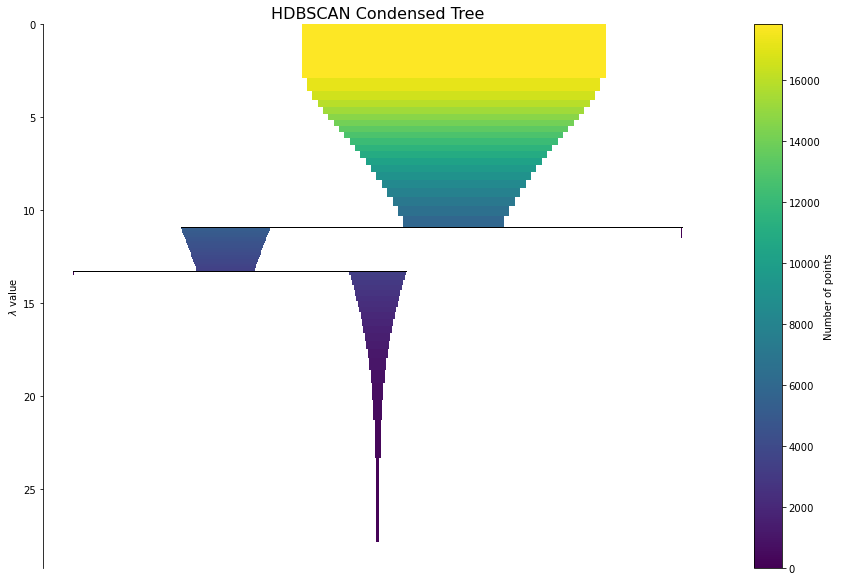

Condensed Tree with Cluster Colours Applied.


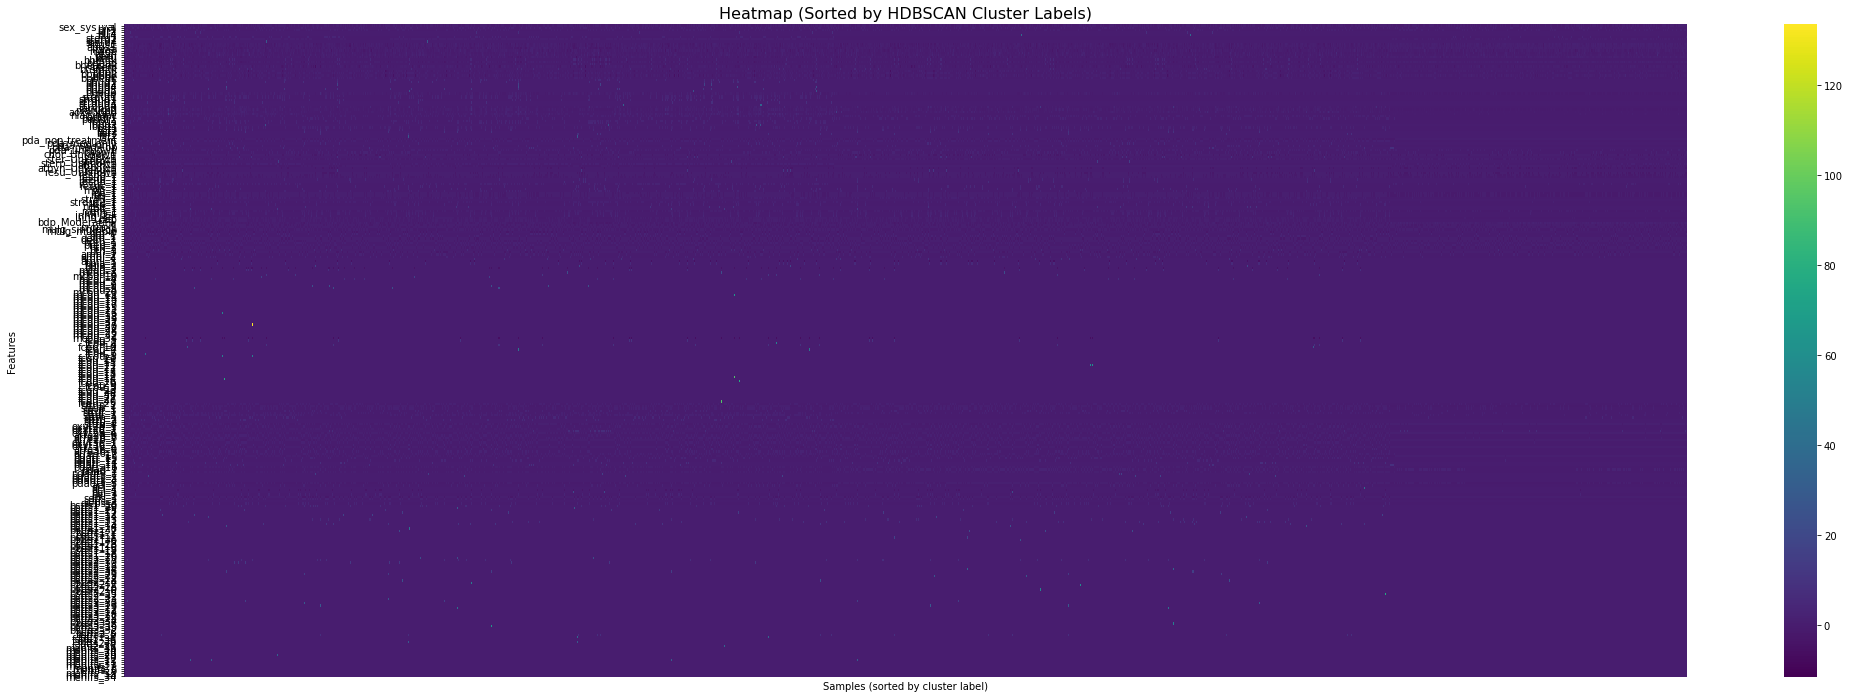

Heatmap saved.
Silhouette Score (all labels incl. noise): -0.1891


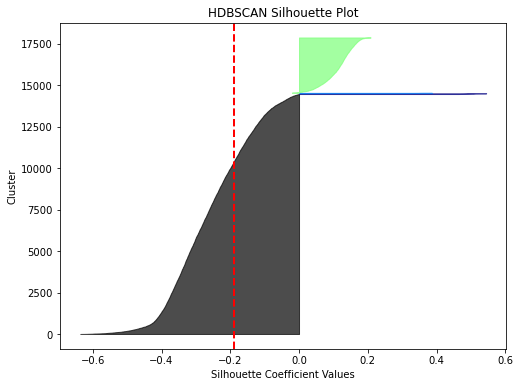

          sex_sys_val      bir1      bir2      bir3      bir4    sterd1  \
idx_code                                                                  
0             1.00028 -0.441286 -0.490886 -0.127909 -0.025952 -0.303196   
1             1.00028 -0.441286 -0.490886 -0.127909 -0.025952 -0.303196   
2             1.00028  2.266106 -0.490886 -0.127909 -0.025952 -0.303196   
3             1.00028 -0.441286  2.037134 -0.127909 -0.025952 -0.303196   
4             1.00028 -0.441286 -0.490886 -0.127909 -0.025952 -0.303196   
...               ...       ...       ...       ...       ...       ...   
17824        -0.99972 -0.441286 -0.490886 -0.127909 -0.025952 -0.303196   
17825         1.00028  2.266106 -0.490886 -0.127909 -0.025952 -0.303196   
17826        -0.99972 -0.441286 -0.490886 -0.127909 -0.025952 -0.303196   
17827         1.00028 -0.441286  2.037134 -0.127909 -0.025952 -0.303196   
17828         1.00028 -0.441286  2.037134 -0.127909 -0.025952 -0.303196   

            sterd2    st

In [14]:
data_for_clustering = df_scd.drop(columns=['death36'])

print(df_scd.columns, len(df_scd.columns))
print(data_for_clustering.columns, len(data_for_clustering.columns))


def gower_distance_custom(X):
    """
    Custom Gower distance computation that ignores NaN values and
    does not normalize numerical differences. 
    """
    n_samples, n_features = X.shape
    G = np.zeros((n_samples, n_samples))
    
    for i in range(n_features):
        feature = X[:, i]
        if np.issubdtype(feature.dtype, np.number):
            # 수치형 피쳐: 정규화 없이 절대 차이
            diff_matrix = np.abs(feature - feature.reshape(-1, 1))
            diff_matrix[np.isnan(diff_matrix)] = 0  # NaN 무시
            G += diff_matrix
        else:
            # 범주형 피쳐: 동일하면 0, 다르면 1
            feature = feature.astype(str)
            diff_matrix = (feature != feature.reshape(-1, 1)).astype(float)
            G += diff_matrix
    
    # 피쳐 수로 나누어 평균
    G /= n_features
    return G

X = data_for_clustering.to_numpy()

print("Calculating Gower distance matrix...")
distance_matrix = gower_distance_custom(X)
np.save(os.path.join(save_dir, "distance_matrix.npy"), distance_matrix)
print("Distance matrix calculation completed & Saved.")


## HDBSCAN Clustering
# metric='precomputed' : 미리 계산한 거리행렬 사용
clusterer = hdbscan.HDBSCAN(metric='precomputed', gen_min_span_tree=True
                            , min_cluster_size=13    # , min_samples=5
#                             , cluster_selection_epsilon=0.0
                           )
print("Fitting HDBSCAN...")
clusterer.fit(distance_matrix)  # 'distance_matrix' shape: (n_samples, n_samples)

cluster_labels = clusterer.labels_  # -1: noise
n_clusters = len(set(cluster_labels) - {-1})
print(f"Found {n_clusters} clusters (excluding noise)")

# HDBSCAN 모델 객체 저장 (옵션)
with open(os.path.join(save_dir, "HDBSCAN_model.pkl"), "wb") as f:
    pickle.dump(clusterer, f)
print("HDBSCAN model saved.")


# condensed_tree_ (use it as Dendrogramme)
unique_clusters = np.unique(cluster_labels[cluster_labels != -1])  # Noise 제외한 클러스터 ID
palette = sns.color_palette("tab10", len(unique_clusters))
cluster_palette = {cluster: palette[i] for i, cluster in enumerate(unique_clusters)}

plt.figure(figsize=(12, 8))
clusterer.condensed_tree_.plot(
#     select_clusters=True,
#     label_clusters=True,
    selection_palette=[cluster_palette[label] for label in unique_clusters]  # Noise(-1) 제외하고 팔레트 적용
)
plt.title("HDBSCAN Condensed Tree", fontsize=16)
plt.show()

print("Condensed Tree with Cluster Colours Applied.")



# # Dendrogramme :: from single_linkage_tree_
# single_linkage_df = clusterer.single_linkage_tree_.to_pandas()
# n_samples = data_for_clustering.shape[0]

# linkage_matrix = single_linkage_df[['left_child'
#                                     , 'right_child'
#                                     , 'distance'
#                                     , 'size']
#                                   ].to_numpy()
# linkage_matrix[:, 0] = np.where(linkage_matrix[:, 0] < n_samples, linkage_matrix[:, 0], linkage_matrix[:, 0] - n_samples)
# linkage_matrix[:, 1] = np.where(linkage_matrix[:, 1] < n_samples, linkage_matrix[:, 1], linkage_matrix[:, 1] - n_samples)

# # 이 코드에서 덴드로그랩을 제거하자.
# # 히트맵만으로도 충분해.

# with open(os.path.join(save_dir, "Z_objects.pkl"), "wb") as f:
#     pickle.dump(linkage_matrix, f)
# print("HDBSCAN single_linkage_tree -> Scipy linkage saved to Z_objects.pkl")

# clusterer.condensed_tree_.plot(select_clusters=True
#                                , selection_palette=sns.color_palette()
#                               )
# plt.title("HDBSCAN Condensed Tree", fontsize=16)
# plt.show()

# clusterer.condensed_tree_.plot()


# Heatmap Only
sorted_idx = np.argsort(cluster_labels)
data_sorted = data_for_clustering.iloc[sorted_idx]

plt.figure(figsize=(35, 12))
sns.heatmap(data_sorted.T, cmap='viridis', cbar=True, yticklabels=True)
plt.title("Heatmap (Sorted by HDBSCAN Cluster Labels)", fontsize=16)
plt.xlabel("Samples (sorted by cluster label)")
plt.ylabel("Features")
plt.xticks([])

plt.savefig(os.path.join(save_dir, "hdbscan_heatmap.png"))
plt.show()
print("Heatmap saved.")

# Dendro + Heatmap
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18),
#                                gridspec_kw={'height_ratios': [1, 3]})

# dendro = dendrogram(linkage_matrix,
#                     ax=ax1,
#                     orientation='top',
#                     distance_sort='ascending',
#                     no_labels=True,  # x축 레이블 제거
#                     above_threshold_color='grey')
# ax1.set_title("HDBSCAN Single Linkage Dendrogram", fontsize=16)

# sorted_idx = np.argsort(cluster_labels)
# data_sorted = data_for_clustering.iloc[sorted_idx]

# sns.heatmap(data_sorted.T,
#             ax=ax2,
#             cmap='viridis',
#             cbar=False,
#             yticklabels=True)
# ax2.set_title("Heatmap (Sorted by HDBSCAN Cluster Labels)", fontsize=16)
# ax2.set_xlabel("Samples (sorted by cluster label)")
# ax2.set_ylabel("Features")
# ax2.set_xticks([])
# plt.tight_layout()

# plt.savefig(os.path.join(save_dir, "hdbscan_dendrogram_heatmap.png"))
# plt.show()
# plt.close(fig)
# print("Dendrogram + Heatmap saved.")


# Silhouette
if n_clusters > 1:
    try:
        silhouette_avg = silhouette_score(data_for_clustering.fillna(0), cluster_labels)
        print(f"Silhouette Score (all labels incl. noise): {silhouette_avg:.4f}")
        
        sil_values = silhouette_samples(data_for_clustering.fillna(0), cluster_labels)
        
        fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
        y_lower = 10
        unique_labels = np.unique(cluster_labels)
        for c_label in unique_labels:
            c_sil_vals = sil_values[cluster_labels == c_label]
            c_sil_vals.sort()
            size_cluster = c_sil_vals.shape[0]
            y_upper = y_lower + size_cluster
            
            if c_label == -1:
                color = (0, 0, 0)  # noise 검정색
            else:
                color = plt.cm.jet(float(c_label) / (n_clusters + 1))
            
            ax1.fill_betweenx(np.arange(y_lower, y_upper), 
                              0, c_sil_vals, 
                              facecolor=color, edgecolor=color, alpha=0.7)
            y_lower = y_upper + 10
        
        ax1.axvline(silhouette_avg, color="red", linestyle="--", linewidth=2)
        ax1.set_title("HDBSCAN Silhouette Plot")
        ax1.set_xlabel("Silhouette Coefficient Values")
        ax1.set_ylabel("Cluster")
        plt.savefig(os.path.join(save_dir, "hdbscan_silhouette_plot.png"))
        plt.show()
    except ValueError as e:
        print("Silhouette calculation failed:", e)
else:
    print("Only one or zero clusters found, skipping silhouette score.")

# Noise (-1)로 분류된 데이터 확인
noise_mask = (cluster_labels == -1)
noise_points = data_for_clustering[noise_mask]

if np.any(noise_mask) and len(noise_points) > 0:  # Noise 데이터가 있을 경우만 진행
    # 각 클러스터 중심점 계산 (Noise 제외)
    valid_clusters = np.unique(cluster_labels[cluster_labels != -1])  # Noise(-1) 제거된 클러스터 ID 리스트
    cluster_centers = np.array([
        data_for_clustering[cluster_labels == lbl].mean(axis=0)
        for lbl in valid_clusters  # Noise 제외한 클러스터만 사용
    ])

    # Noise 데이터와 클러스터 중심 간 거리 계산
    closest_clusters = np.argmin(cdist(noise_points, cluster_centers), axis=1)

    # Noise 데이터에 가장 가까운 클러스터 할당
    cluster_labels[noise_mask] = valid_clusters[closest_clusters]  # 최근접 클러스터로 Noise 배정

# Noise 제거 후 클러스터 라벨 적용
df_scd['Cluster_Labels'] = cluster_labels + 1
df_scd['death36'] = df['death36']

print(df_scd)
print("All HDBSCAN clustering session completed.")


In [21]:
help(hdbscan.plots)

Help on module hdbscan.plots in hdbscan:

NAME
    hdbscan.plots

DESCRIPTION
    # -*- coding: utf-8 -*-
    # Author: Leland McInnes <leland.mcinnes@gmail.com>
    #
    # License: BSD 3 clause

CLASSES
    builtins.object
        CondensedTree
        MinimumSpanningTree
        SingleLinkageTree
    
    class CondensedTree(builtins.object)
     |  CondensedTree(condensed_tree_array, cluster_selection_method='eom', allow_single_cluster=False)
     |  
     |  The condensed tree structure, which provides a simplified or smoothed version
     |  of the :class:`~hdbscan.plots.SingleLinkageTree`.
     |  
     |  Parameters
     |  ----------
     |  condensed_tree_array : numpy recarray from :class:`~hdbscan.HDBSCAN`
     |      The raw numpy rec array version of the condensed tree as produced
     |      internally by hdbscan.
     |  
     |  cluster_selection_method : string, optional (default 'eom')
     |      The method of selecting clusters. One of 'eom' or 'leaf'
     |  
    

In [46]:
# 저장된 HDBSCAN 모델 불러오기
with open(os.path.join(out, "HDBSCAN_model.pkl"), "rb") as f:
    clusterer = pickle.load(f)

# 클러스터 선택 파라미터 설정
clusterer.condensed_tree_.set_select_parameters(
    min_cluster_size=10, 
    cluster_selection_epsilon=0.05,
)
new_labels = clusterer.condensed_tree_.get_clusters()

# 원본 데이터에서 클러스터링 데이터 준비
data_for_clustering = df_scd.drop(columns=['death36'])
cluster_labels = clusterer.labels_
n_clusters = len(set(cluster_labels) - {-1})  # Noise(-1) 제외한 클러스터 개수

# 클러스터별 Silhouette Score 계산
if n_clusters > 1:
    sil_vals = silhouette_samples(data_for_clustering.fillna(0), cluster_labels)
    sil_scores = {
        lbl: np.mean(sil_vals[cluster_labels == lbl])
        for lbl in np.unique(cluster_labels) if lbl in new_labels  # Noise(-1) 제외, 클러스터만 포함
    }
    print("Cluster-wise Silhouette Scores:")
    for lbl, score in sil_scores.items():
        print(f"Cluster {lbl}: {score:.4f}")
else:
    print("Only one cluster found, skipping silhouette score calculation.")

# Heatmap 시각화
sorted_idx = np.argsort(cluster_labels)
data_sorted = data_for_clustering.iloc[sorted_idx]

plt.figure(figsize=(35, 18))
sns.heatmap(data_sorted.T, cbar=False, cmap='viridis', yticklabels=True)
plt.xlabel('Individual Encounters', fontsize=25, fontweight='bold')
plt.ylabel('Variables', fontsize=25, fontweight='bold')
plt.xticks([])
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"cluster_analysis_{n_clusters}_clusters.png"))
plt.show()
plt.close()

print("Heatmap saved.")

# CondensedTree Plot 추가
plt.figure(figsize=(12, 8))
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette())
plt.title("HDBSCAN Condensed Tree", fontsize=16)
plt.show()

# 데이터프레임에 클러스터 라볼 반영
df_scd['Cluster_Labels'] = cluster_labels + 1  # -1이 noise이니보다 +1 적용
df_scd['death36'] = df_scd['death36']  # 기존 데이터 유지

print(f"Clustering completed with {n_clusters} clusters.")
print(df_scd)

AttributeError: 'CondensedTree' object has no attribute 'set_select_parameters'

In [41]:
# with open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:
#     linkage_matrix = pickle.load(f)

# # 2) 사용자 지정 클러스터 수
# n_clusters = 3

# # 3) fcluster를 통해 "n_clusters"로 자르기
# cluster_labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
# print(f"n_clusters = {n_clusters}: {np.unique(cluster_labels)} unique labels")


# Model import
with open(os.path.join(out, "HDBSCAN_model.pkl"), "rb") as f:
    clusterer = pickle.load(f)

clusterer.condensed_tree_.set_select_parameters(
    min_cluster_size=10, 
    cluster_selection_epsilon=0.05,
#     cluster_selection_method='leaf'
)
new_labels = clusterer.condensed_tree_.get_clusters()

# 4) 원본 데이터(= df_scd.drop(columns=['death36']) etc.) 로 silhouette 등 측정
data_for_clustering = df_scd.drop(columns=['death36'])

sil_vals = silhouette_samples(data_for_clustering.fillna(0), cluster_labels)
sil_avg = np.mean(sil_vals)
sil_std_dev = np.std([np.mean(sil_vals[cluster_labels == lbl]) for lbl in np.unique(cluster_labels)])
print(f"For n_clusters = {n_clusters},\nAverage Silhouette_score: {sil_avg:.4f},\nstd deviation: {sil_std_dev:.4f}\n")

# 5) dendrogram + heatmap 재시각화 (원하면)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18),
                               gridspec_kw={'height_ratios': [1, 3]})

# Dendrogram
threshold = linkage_matrix[-(n_clusters - 1), 2]
dendrogram(linkage_matrix,
           ax=ax1,
           orientation='top',
           color_threshold=threshold,
           above_threshold_color='grey',
           no_labels=True)
ax1.set_xticks([])
ax1.set_yticks([])

sorted_idx = dendrogram(linkage_matrix, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]

sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)
plt.tight_layout()

plt.savefig(os.path.join(save_dir, f"cluster_analysis_{n_clusters}_clusters.png"))
plt.show()
plt.close(fig)

# 데이터프레임에 클러스터 라벨 반영
df_scd['Cluster_Labels'] = cluster_labels +1
df_scd['death36'] = df['death36']

print(f"Clustering completed with {n_clusters} clusters.")
print(df_scd)


AttributeError: 'CondensedTree' object has no attribute 'set_select_parameters'

In [15]:
print(df_scd['Cluster_Labels'].value_counts().sort_index())
print(df_scd.isnull().sum())

1      234
2     5439
3    12156
Name: Cluster_Labels, dtype: int64
sex_sys_val       0
bir1              0
bir2              0
bir3              0
bir4              0
                 ..
menifs_33         0
menifs_18         0
menifs_34         0
death36           0
Cluster_Labels    0
Length: 290, dtype: int64


In [16]:
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered.csv"))

In [17]:
## Merge Cluster_Labels to original dataframe
df_combined = df.merge(df_scd[['Cluster_Labels']]
                       , left_index=True, right_index=True
                       , how='left'
                      )
df_combined

,sex_sys_val,bir1,bir2,bir3,bir4,sterd1,sterd2,sterd4,apgs1,apgs5,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,...,0,1,0,0,0,1,0,0,0,2
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,...,0,1,0,0,0,1,0,0,0,3
2,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,6.0,...,0,1,0,0,0,1,0,0,0,3
3,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.0,7.0,...,0,1,0,0,0,1,0,0,0,2
4,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,...,0,1,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17824,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0,...,0,1,0,0,0,1,0,0,0,2
17825,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,6.0,...,0,1,0,0,0,1,0,0,0,3
17826,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,8.0,...,0,0,1,0,0,0,1,0,0,3


In [18]:
df_combined.to_csv(os.path.join(save_dir, "KNN_df_combined.csv"))

In [19]:
# WILCOXON TEST

# Declare input data
input_df = df_combined

# 고유 클러스터 값과 클러스터 수 계산
unique_clusters = input_df['Cluster_Labels'].unique()
num_clusters = len(unique_clusters)

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for i in unique_clusters:
    cluster_data = input_df[input_df['Cluster_Labels'] == i]
    outside_data = input_df[input_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in input_df.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(input_df[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats[column] = f"{mean_val:.4f} ± {std_dev:.4f}"
                if p_value < 0.01:
                    formatted_p_value = f"{p_value:.4e}" if p_value < 0.0001 else f"{p_value:.4f}"
                    p_values[column] = formatted_p_value
                else:
                    p_values[column] = "n.s."
            else:
                stats[column] = "NaN ± NaN"
                p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과를 DataFrame으로 결합
combined_df = pd.DataFrame()
for i in unique_clusters:
    combined_stats = stats_df[f'Cluster {i}'] + " (" + p_values_df[f'Cluster {i}'] + ")"
    combined_df[f'Cluster {i}'] = combined_stats

# Cluster 열을 이름을 기준으로 정렬
combined_df = combined_df.reindex(sorted(combined_df.columns), axis=1)

# 결과 출력
print("Combined Mean, Standard Deviation and P-values:")
print(combined_df)

Combined Mean, Standard Deviation and P-values:
                            Cluster 1                     Cluster 2  \
sex_sys_val    0.5085 ± 0.5010 (n.s.)      0.4799 ± 0.4996 (0.0004)   
bir1           0.1581 ± 0.3656 (n.s.)        0.1699 ± 0.3756 (n.s.)   
bir2           0.2521 ± 0.4352 (n.s.)        0.1993 ± 0.3995 (n.s.)   
bir3         0.0470 ± 0.2121 (0.0002)        0.0153 ± 0.1226 (n.s.)   
bir4           0.0000 ± 0.0000 (n.s.)        0.0006 ± 0.0235 (n.s.)   
...                               ...                           ...   
iperr_4        0.0000 ± 0.0000 (n.s.)        0.0007 ± 0.0271 (n.s.)   
iperroy_1      0.9701 ± 0.1707 (n.s.)  0.9643 ± 0.1855 (6.8321e-12)   
iperroy_4      0.0043 ± 0.0654 (n.s.)        0.0033 ± 0.0574 (n.s.)   
iperroy_3      0.0214 ± 0.1449 (n.s.)  0.0298 ± 0.1700 (2.0701e-11)   
iperroy_2      0.0043 ± 0.0654 (n.s.)        0.0026 ± 0.0507 (n.s.)   

                                Cluster 3  
sex_sys_val      0.5086 ± 0.4999 (0.0006)  
bir1       

In [20]:
combined_df.to_csv(os.path.join(save_dir, "KNN_df_combined_wilcoxon+p_val.csv")
                   , encoding='utf-8-sig'    # '±'표현을 위해 encoding='utf-8-sig' 사용
                  )

In [21]:
## Main FEATURE RATIO
# 'Cluster_Labels'와 'death_label' 확인
def calculate_positive_rate(ipt_df, ipt_col):
    # 'Cluster_Labels'와 ipt_col 확인
    if 'Cluster_Labels' in ipt_df.columns and ipt_col in ipt_df.columns:
        results_df = pd.DataFrame()

        # 각 클러스터의 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = (cluster_data[ipt_col] == 1).sum()
            negative_count = (cluster_data[ipt_col] == 0).sum()

            # 칼럼 이름에서 언더바 이후를 제거
            display_col = ipt_col.split('_')[0]

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and '{ipt_col}'"


# iperr_3
# iperr_4

# ntet_1
# iperr_2
# death36
cmr = calculate_positive_rate(df_combined, 'death36')
cmr1 = calculate_positive_rate(df_combined, 'ntet_1')
cmr2 = calculate_positive_rate(df_combined, 'iperr_2')
print(cmr, cmr1, cmr2)

             Total  death36_Pos  death36_Neg Positive Rate death36_Pos / Total
Cluster 1    234.0         19.0        215.0         8.12%            19 / 234
Cluster 2   5439.0        131.0       5308.0         2.41%          131 / 5439
Cluster 3  12156.0        190.0      11966.0         1.56%         190 / 12156              Total  ntet_Pos  ntet_Neg Positive Rate ntet_Pos / Total
Cluster 1    234.0      19.0     215.0         8.12%         19 / 234
Cluster 2   5439.0     494.0    4945.0         9.08%       494 / 5439
Cluster 3  12156.0     662.0   11494.0         5.45%      662 / 12156              Total  iperr_Pos  iperr_Neg Positive Rate iperr_Pos / Total
Cluster 1    234.0        7.0      227.0         2.99%           7 / 234
Cluster 2   5439.0      194.0     5245.0         3.57%        194 / 5439
Cluster 3  12156.0      224.0    11932.0         1.84%       224 / 12156


In [22]:
cmr.to_csv(os.path.join(save_dir, "mortality_rate_results_death36.csv"), encoding='utf-8-sig')
cmr1.to_csv(os.path.join(save_dir, "mortality_rate_results_ntetPos.csv"), encoding='utf-8-sig')
cmr2.to_csv(os.path.join(save_dir, "mortality_rate_results_iperrPos.csv"), encoding='utf-8-sig')

In [23]:
# Result function : 'n' about 2+ Cols

def calculate_positive_rate(ipt_df, ipt_cols):
    # 'Cluster_Labels'와 ipt_cols가 존재하는지 확인
    if 'Cluster_Labels' in ipt_df.columns and all(col in ipt_df.columns for col in ipt_cols):
        results_df = pd.DataFrame()

        # 두 칼럼 전부 1인 경우를 Positive로 간주 ('And' Condition)
        ipt_df['combined_Positive'] = (ipt_df[ipt_cols[0]] == 1) & (ipt_df[ipt_cols[1]] == 1)

        # 각 클러스터별 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = cluster_data['combined_Positive'].sum()
            negative_count = total_count - positive_count

            # 칼럼 이름 조합하여 표시
            display_col = "_and_".join([col.split('_')[0] for col in ipt_cols])

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 'combined_Positive' 칼럼 삭제 (원본 유지)
        ipt_df.drop(columns=['combined_Positive'], inplace=True)

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and {ipt_cols}"

# 사용 예시
cmr3 = calculate_positive_rate(df_combined, ['ntet_1', 'iperr_2'])
print(cmr3)

             Total  ntet_and_iperr_Pos  ntet_and_iperr_Neg Positive Rate  \
Cluster 1    234.0                 3.0               231.0         1.28%   
Cluster 2   5439.0                72.0              5367.0         1.32%   
Cluster 3  12156.0                59.0             12097.0         0.49%   

          ntet_and_iperr_Pos / Total  
Cluster 1                    3 / 234  
Cluster 2                  72 / 5439  
Cluster 3                 59 / 12156  


In [24]:
cmr3.to_csv(os.path.join(save_dir, "mortality_rate_results_iperr&ntet.csv"), encoding='utf-8-sig')